In [1]:
import os

print(os.listdir('/kaggle/input'))

['competitions']


In [2]:
for item in os.listdir('/kaggle/input'):
    print(item)

competitions


In [3]:
BASE_PATH = '/kaggle/input/competitions/rsna-knee-abnormality-detection'

print(os.listdir(BASE_PATH))

['test_series.csv', 'train_series.csv', 'sample_submission.csv', 'test_series', 'train_series', 'train.csv', 'test.csv']


In [4]:
import pandas as pd
import os

train = pd.read_csv(os.path.join(BASE_PATH, "train.csv"))

print("Shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())

display(train.head())

Shape: (4407, 14)

Columns:
['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StudyInstanceUID  4407 non-null   object 
 1   Report            4407 non-null   object 
 2   ACL               58 non-null     float64
 3   MCL               58 non-null     float64
 4   Medial Meniscus   58 non-null     float64
 5   Lateral Meniscus  58 non-null     float64
 6   Medial OA         58 non-null     float64
 7   Lateral OA        58 non-null     float64
 8   PF OA             58 non-null     float64
 9   Effusion          58 non-null     float64
 10  Synovitis         58 non-null     float64
 11  Baker's           58 non-null     float64
 12  Contusion         58 non-null     float64
 13  Fracture          58 non-null     float64
dtypes: float64(12), object(2)
memory usage: 482.1+ KB


In [6]:
print(train[['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
             'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
             'Synovitis', "Baker's", 'Contusion', 'Fracture']].notna().sum())

ACL                 58
MCL                 58
Medial Meniscus     58
Lateral Meniscus    58
Medial OA           58
Lateral OA          58
PF OA               58
Effusion            58
Synovitis           58
Baker's             58
Contusion           58
Fracture            58
dtype: int64


In [7]:
display(train[train['ACL'].notna()].head())

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
63,1.2.826.0.1.3680043.8.498.10170898615867673028...,The study reveals normal knee joint alignment...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
109,1.2.826.0.1.3680043.8.498.10306159113324811538...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
445,1.2.826.0.1.3680043.8.498.11287937729196958426...,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
470,1.2.826.0.1.3680043.8.498.11382021393803389951...,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_series = pd.read_csv(
    os.path.join(BASE_PATH, "train_series.csv")
)

print("Shape:", train_series.shape)
print("Columns:", train_series.columns.tolist())

display(train_series.head())

Shape: (24371, 5)
Columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [9]:
train_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24371 entries, 0 to 24370
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   StudyInstanceUID   24371 non-null  object
 1   SeriesInstanceUID  24371 non-null  object
 2   Fluid_Sensitive    24371 non-null  int64 
 3   Fat_Suppression    24371 non-null  int64 
 4   Anatomical_Plane   24371 non-null  object
dtypes: int64(2), object(3)
memory usage: 952.1+ KB


In [10]:
train_series['Anatomical_Plane'].value_counts()

Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

In [11]:
train_series['Fluid_Sensitive'].value_counts()

Fluid_Sensitive
1    14010
0    10361
Name: count, dtype: int64

In [12]:
train_series['Fat_Suppression'].value_counts()

Fat_Suppression
1    14010
0    10361
Name: count, dtype: int64

In [13]:
series_per_study = train_series.groupby('StudyInstanceUID').size()

print(series_per_study.describe())

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


In [14]:
labeled_study = train[train['ACL'].notna()].iloc[0]['StudyInstanceUID']

print(labeled_study)

1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149


In [15]:
study_series = train_series[
    train_series['StudyInstanceUID'] == labeled_study
]

print(study_series.shape)
display(study_series)

(5, 5)


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
163,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,0,Sagittal
164,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.12451507871565834868...,0,0,Coronal
165,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial


In [16]:
series_uid = study_series.iloc[3]['SeriesInstanceUID']

print(series_uid)

1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429


In [17]:
study_uid = labeled_study

print("Study UID:", study_uid)
print("Series UID:", series_uid)

Study UID: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
Series UID: 1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429


In [18]:
series_path = os.path.join(
    BASE_PATH,
    "train_series",
    study_uid,
    series_uid
)

print(series_path)
print(os.path.exists(series_path))

/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429
True


In [19]:
dicom_files = sorted(os.listdir(series_path))

print("Number of files:", len(dicom_files))
print("First 5 files:", dicom_files[:5])

Number of files: 36
First 5 files: ['1.2.826.0.1.3680043.8.498.10510575059177468411555373275759922508.dcm', '1.2.826.0.1.3680043.8.498.10952016037843177599128697353782635584.dcm', '1.2.826.0.1.3680043.8.498.11173384594863599162701922864860545586.dcm', '1.2.826.0.1.3680043.8.498.11412319853384360156851724961091181876.dcm', '1.2.826.0.1.3680043.8.498.11674795861279575960305380899707531245.dcm']


In [20]:
import pydicom
import os

slices = []

for file in dicom_files:
    path = os.path.join(series_path, file)
    ds = pydicom.dcmread(path)
    slices.append(ds)

print("Number of slices:", len(slices))
print("Image shape:", slices[0].pixel_array.shape)

Number of slices: 36
Image shape: (320, 320)


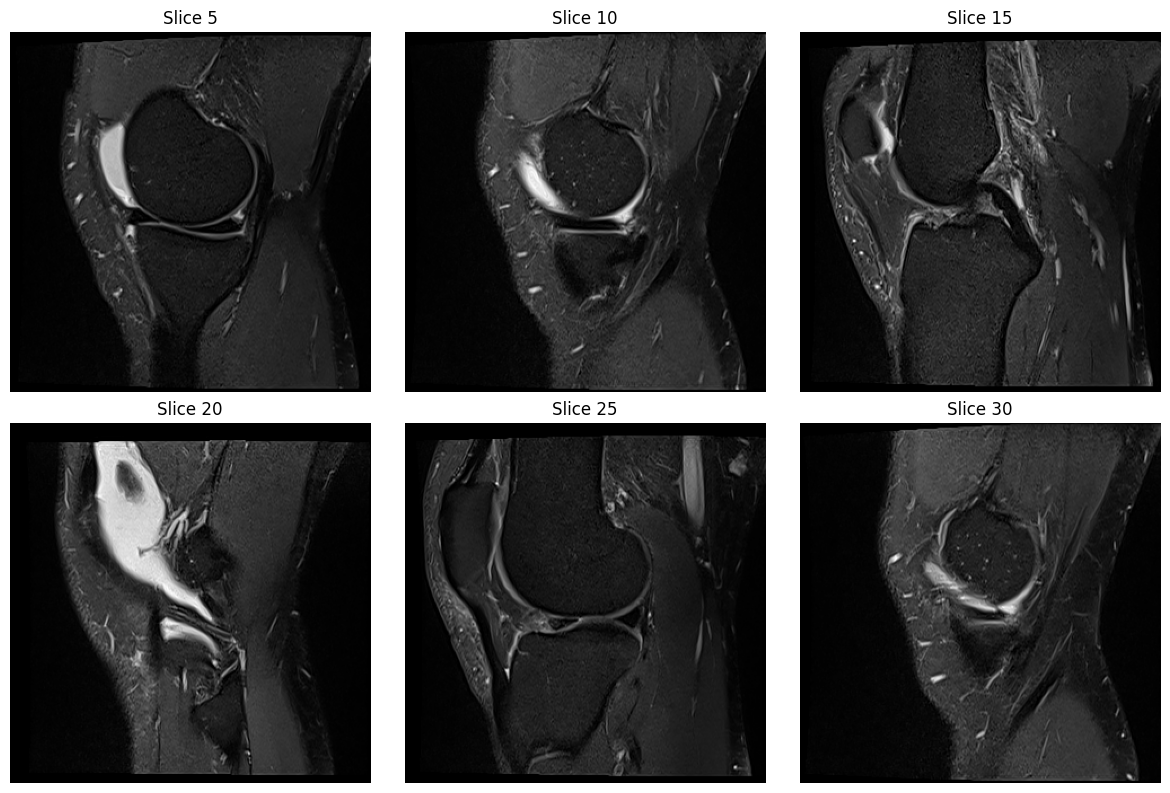

In [21]:
import matplotlib.pyplot as plt

indices = [5, 10, 15, 20, 25, 30]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, i in zip(axes.ravel(), indices):
    ax.imshow(slices[i].pixel_array, cmap='gray')
    ax.set_title(f"Slice {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
study_info = train[train['StudyInstanceUID'] == study_uid]

display(
    study_info[
        ['StudyInstanceUID', 'Report', 'ACL', 'MCL',
         'Medial Meniscus', 'Lateral Meniscus',
         'Medial OA', 'Lateral OA', 'PF OA',
         'Effusion', 'Synovitis', "Baker's",
         'Contusion', 'Fracture']
    ]
)

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [23]:
label_cols = [
    'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
    'Medial OA', 'Lateral OA', 'PF OA',
    'Effusion', 'Synovitis', "Baker's",
    'Contusion', 'Fracture'
]

label_counts = train[label_cols].dropna().sum().sort_values(ascending=False)

print("Number of positive cases:")
display(label_counts)

Number of positive cases:


Effusion            35.0
Synovitis           27.0
Medial Meniscus     26.0
ACL                 24.0
Lateral Meniscus    23.0
PF OA               21.0
Contusion           19.0
Fracture            18.0
Medial OA           15.0
Baker's             12.0
Lateral OA          11.0
MCL                  9.0
dtype: float64

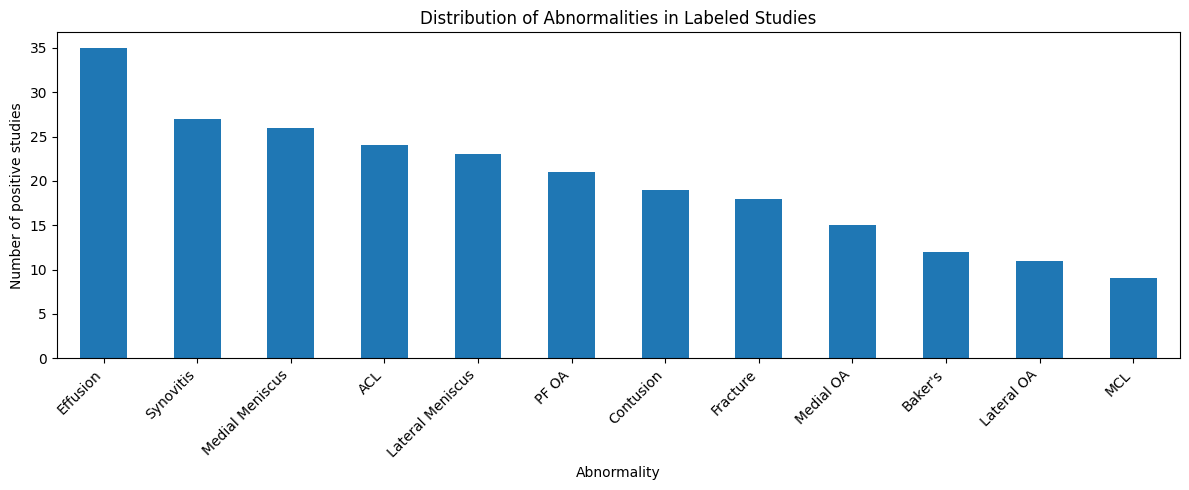

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.ylabel("Number of positive studies")
plt.xlabel("Abnormality")
plt.title("Distribution of Abnormalities in Labeled Studies")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
print("Total studies:", train['StudyInstanceUID'].nunique())
print("Labeled studies:", train[train['ACL'].notna()]['StudyInstanceUID'].nunique())
print("Total series:", train_series['SeriesInstanceUID'].nunique())

Total studies: 4407
Labeled studies: 58
Total series: 24371


In [26]:
print("Missing labels:")
display(train[label_cols].isna().sum())

Missing labels:


ACL                 4349
MCL                 4349
Medial Meniscus     4349
Lateral Meniscus    4349
Medial OA           4349
Lateral OA          4349
PF OA               4349
Effusion            4349
Synovitis           4349
Baker's             4349
Contusion           4349
Fracture            4349
dtype: int64

In [27]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def load_dicom_series(series_path):
#    Load all DICOM files from a series and sort them using DICOM spatial metadata.
    dicom_slices = []
    for filename in os.listdir(series_path):
        filepath = os.path.join(series_path, filename)
        try:
            ds = pydicom.dcmread(filepath)
            # Make sure the file contains image data
            if hasattr(ds, "PixelData"):
                dicom_slices.append(ds)
        except Exception as e:
            print(f"Could not read {filename}: {e}")
    # Sort using ImagePositionPatient when available
    if all(hasattr(ds, "ImagePositionPatient") for ds in dicom_slices):
        dicom_slices.sort(key=lambda ds: float(ds.ImagePositionPatient[2]))
    # Otherwise fall back to InstanceNumber
    elif all(hasattr(ds, "InstanceNumber") for ds in dicom_slices):
        dicom_slices.sort( key=lambda ds: int(ds.InstanceNumber))

    return dicom_slices

In [29]:
ordered_slices = load_dicom_series(series_path)

print("Number of slices:", len(ordered_slices))
print("Image shape:", ordered_slices[0].pixel_array.shape)

Number of slices: 36
Image shape: (320, 320)


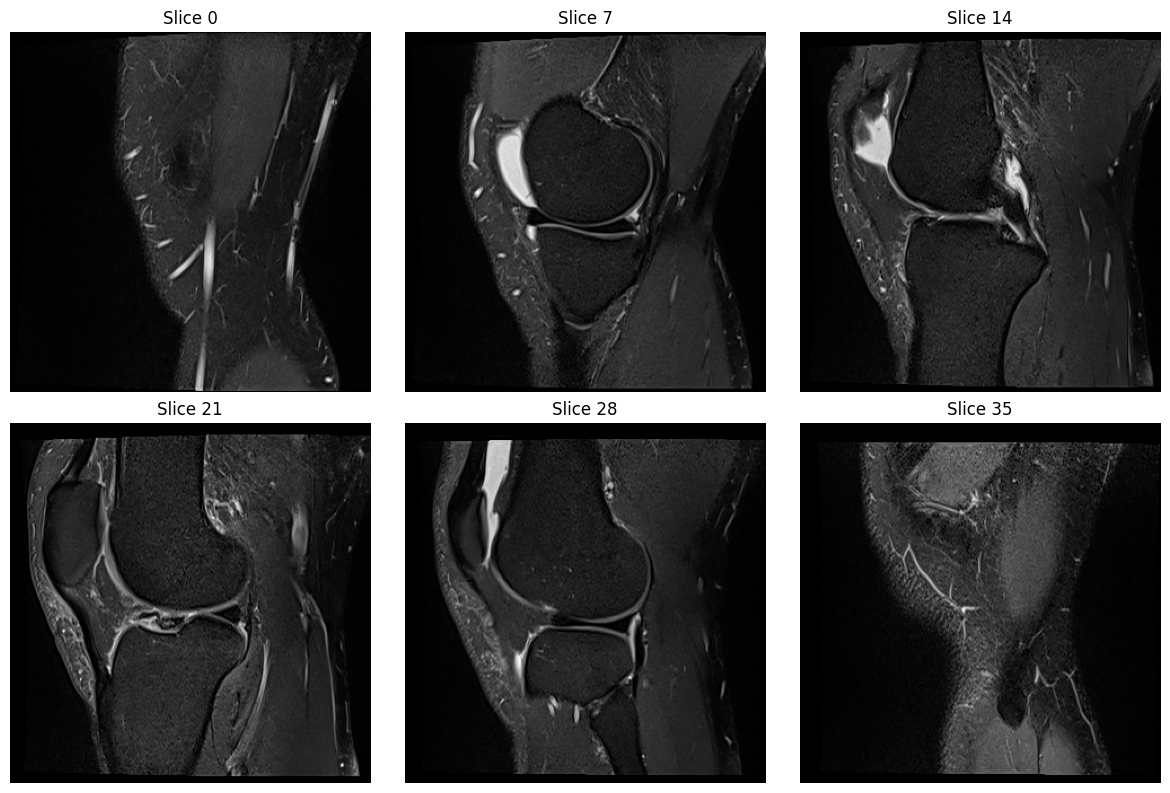

In [30]:
indices = np.linspace(
    0,
    len(ordered_slices) - 1,
    6,
    dtype=int
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, i in zip(axes.ravel(), indices):
    ax.imshow(
        ordered_slices[i].pixel_array,
        cmap="gray"
    )
    ax.set_title(f"Slice {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
ds = ordered_slices[len(ordered_slices)//2]

metadata_fields = [
    "PatientID",
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "Modality",
    "Manufacturer",
    "MagneticFieldStrength",
    "SliceThickness",
    "SpacingBetweenSlices",
    "PixelSpacing",
    "ImageOrientationPatient",
    "ImagePositionPatient",
    "InstanceNumber",
    "Rows",
    "Columns"
]

for field in metadata_fields:
    if hasattr(ds, field):
        print(f"{field}: {getattr(ds, field)}")

PatientID: e0f1600d-2e2
StudyInstanceUID: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
SeriesInstanceUID: 1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429
Modality: MR
Manufacturer: Siemens Healthineers
MagneticFieldStrength: 1.5
SliceThickness: 2.5
SpacingBetweenSlices: 2.875
PixelSpacing: [0.5, 0.5]
ImageOrientationPatient: [-0.0703218, 0.987788, 0.139034, -0.109149, 0.130922, -0.985366]
ImagePositionPatient: [-96.3461, -141.06, 85.8924]
InstanceNumber: 18
Rows: 320
Columns: 320


In [32]:
def get_pixel_array(dicom_slices):
   # Convert DICOM slices into a NumPy array.
    images = []
    for ds in dicom_slices:
        image = ds.pixel_array.astype(np.float32)
        images.append(image)
    return np.stack(images)

In [33]:
volume = get_pixel_array(ordered_slices)

print("Volume shape:", volume.shape)
print("Data type:", volume.dtype)
print("Minimum:", volume.min())
print("Maximum:", volume.max())

Volume shape: (36, 320, 320)
Data type: float32
Minimum: 0.0
Maximum: 788.0


In [34]:
def normalize_volume(volume):    
    lower = np.percentile(volume, 1)
    upper = np.percentile(volume, 99)
    volume = np.clip(volume, lower, upper)
    volume = (volume - lower) / (upper - lower + 1e-8)
    return volume

In [35]:
normalized_volume = normalize_volume(volume)

print("Minimum:", normalized_volume.min())
print("Maximum:", normalized_volume.max())

Minimum: 0.0
Maximum: 1.0


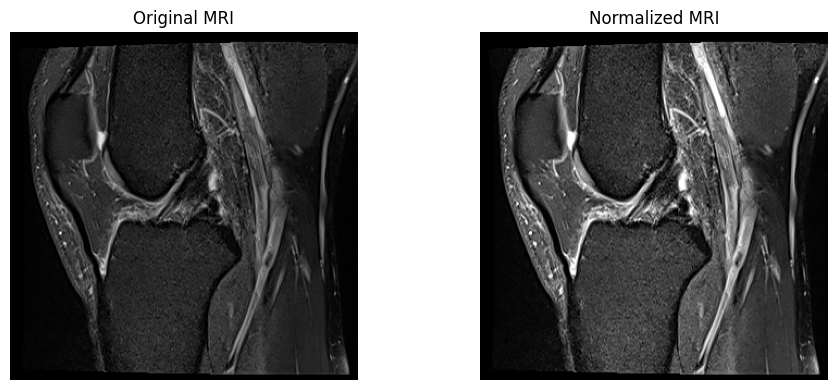

In [36]:
middle = len(normalized_volume) // 2

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    volume[middle],
    cmap="gray"
)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    normalized_volume[middle],
    cmap="gray"
)
plt.title("Normalized MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
def get_candidate_series(study_uid, train_series):    
    candidates = train_series[
        (train_series["StudyInstanceUID"] == study_uid) &
        (train_series["Fluid_Sensitive"] == 1) &
        (train_series["Fat_Suppression"] == 1)
    ].copy()
    
    return candidates

In [38]:
candidates = get_candidate_series(study_uid, train_series)

print("Study UID:", study_uid)
print("Number of candidate series:", len(candidates))

display(candidates)

Study UID: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
Number of candidate series: 3


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
165,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial


In [39]:
display(
    candidates[
        ["SeriesInstanceUID",
         "Fluid_Sensitive",
         "Fat_Suppression",
         "Anatomical_Plane"]
    ]
)

,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
165,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial
